In [202]:
!pip install seaborn


In [203]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score
)

In [204]:
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    DEVICE
)

Device: cuda


In [205]:
PROJECT_ROOT = Path("../")

TEST_RGB_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/test/images"
)

TEST_MASK_DIR = (
    PROJECT_ROOT /
    "dataset/processed/STRUM/test/masks"
)

TEST_SAM_DIR = (
    PROJECT_ROOT /
    "dataset/sam_embeddings/strum_rgb_vit_b/test"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT /
    "checkpoints"
)

BASELINE_WEIGHT = (
    CHECKPOINT_DIR /
    "best_baseline_unet.pth"
)

HYBRID_WEIGHT = (
    CHECKPOINT_DIR /
    "best_hybrid_sam_unet.pth"
)

In [206]:
print(TEST_RGB_DIR.exists())
print(TEST_MASK_DIR.exists())
print(TEST_SAM_DIR.exists())

print(BASELINE_WEIGHT.exists())
print(HYBRID_WEIGHT.exists())

True
True
True
True
True


In [207]:
print(TEST_RGB_DIR.exists())
print(TEST_MASK_DIR.exists())
print(TEST_SAM_DIR.exists())

print(BASELINE_WEIGHT.exists())
print(HYBRID_WEIGHT.exists())

True
True
True
True
True


In [208]:
test_rgb_paths = sorted(
    TEST_RGB_DIR.glob("*.npy")
)

test_mask_paths = sorted(
    TEST_MASK_DIR.glob("*.npy")
)

test_sam_paths = sorted(
    TEST_SAM_DIR.glob("*.npy")
)

print(
    len(test_rgb_paths)
)

print(
    len(test_mask_paths)
)

print(
    len(test_sam_paths)
)

268
268
268


In [209]:
class TestFloodDataset(Dataset):

    def __init__(
        self,
        rgb_paths,
        mask_paths,
        sam_paths
    ):

        self.rgb_paths = rgb_paths
        self.mask_paths = mask_paths
        self.sam_paths = sam_paths

    def __len__(self):

        return len(
            self.rgb_paths
        )

    def __getitem__(
        self,
        idx
    ):

        image = np.load(
            self.rgb_paths[idx]
        ).astype(np.float32)

        mask = np.load(
            self.mask_paths[idx]
        ).astype(np.float32)

        sam_feature = np.load(
            self.sam_paths[idx]
        ).astype(np.float32)

        mask = np.expand_dims(
            mask,
            axis=0
        )

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

        sam_feature = torch.tensor(
            sam_feature,
            dtype=torch.float32
        )

        return (
            image,
            mask,
            sam_feature
        )

In [210]:
test_dataset = TestFloodDataset(
    test_rgb_paths,
    test_mask_paths,
    test_sam_paths
)

print(
    len(test_dataset)
)

268


In [211]:
test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

In [212]:
images, masks, sams = next(
    iter(test_loader)
)

print(
    images.shape
)

print(
    masks.shape
)

print(
    sams.shape
)

print(
    images.dtype
)

print(
    sams.dtype
)

torch.Size([8, 3, 128, 128])
torch.Size([8, 1, 128, 128])
torch.Size([8, 256, 64, 64])
torch.float32
torch.float32


In [236]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True)

        )

    def forward(
        self,
        x
    ):

        return self.conv(x)

In [237]:
class UNet(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=1
    ):

        super().__init__()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.down1 = DoubleConv(
            in_channels,
            64
        )

        self.down2 = DoubleConv(
            64,
            128
        )

        self.down3 = DoubleConv(
            128,
            256
        )

        self.down4 = DoubleConv(
            256,
            512
        )

        self.bottleneck = DoubleConv(
            512,
            1024
        )

        self.dropout = nn.Dropout2d(
            0.5
        )

        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(
            1024,
            512
        )

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            512,
            256
        )

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            256,
            128
        )

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            128,
            64
        )

        self.final = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )

    def forward(
        self,
        x
    ):

        d1 = self.down1(x)

        d2 = self.down2(
            self.pool(d1)
        )

        d3 = self.down3(
            self.pool(d2)
        )

        d4 = self.down4(
            self.pool(d3)
        )

        bottleneck = self.bottleneck(
            self.pool(d4)
        )

        bottleneck = self.dropout(
            bottleneck
        )

        u4 = self.up4(
            bottleneck
        )

        u4 = torch.cat(
            [u4, d4],
            dim=1
        )

        u4 = self.dec4(u4)

        u3 = self.up3(u4)

        u3 = torch.cat(
            [u3, d3],
            dim=1
        )

        u3 = self.dec3(u3)

        u2 = self.up2(u3)

        u2 = torch.cat(
            [u2, d2],
            dim=1
        )

        u2 = self.dec2(u2)

        u1 = self.up1(u2)

        u1 = torch.cat(
            [u1, d1],
            dim=1
        )

        u1 = self.dec1(u1)

        return self.final(u1)

In [239]:
baseline_model = UNet().to(
    DEVICE
)

baseline_model.load_state_dict(
    torch.load(
        BASELINE_WEIGHT,
        map_location=DEVICE
    )
)

baseline_model.eval()

print(
    "Baseline Loaded Successfully"
)

Baseline Loaded Successfully


In [238]:
baseline_model = UNet().to(
    DEVICE
)

print(
    sum(
        p.numel()
        for p in baseline_model.parameters()
    )
)

31037633


In [216]:
print(
    sum(
        p.numel()
        for p in baseline_model.parameters()
    )
)

31037633


In [240]:
images, masks, sams = next(
    iter(test_loader)
)

with torch.no_grad():

    outputs = baseline_model(
        images.to(DEVICE)
    )

print(outputs.shape)

torch.Size([8, 1, 128, 128])


In [241]:
DROPOUT_RATE = 0.5

In [242]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            )
        )

    def forward(
        self,
        x
    ):
        return self.block(x)

In [243]:
class EncoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

        self.pool = nn.MaxPool2d(
            2
        )

    def forward(
        self,
        x
    ):

        features = self.conv(x)

        pooled = self.pool(
            features
        )

        return (
            features,
            pooled
        )

In [244]:
class DecoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            out_channels +
            skip_channels,
            out_channels
        )

    def forward(
        self,
        x,
        skip
    ):

        x = self.up(x)

        x = torch.cat(
            [skip, x],
            dim=1
        )

        x = self.conv(x)

        return x

In [245]:
class HybridSAMUNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.enc1 = EncoderBlock(
            3,
            64
        )

        self.enc2 = EncoderBlock(
            64,
            128
        )

        self.sam_reduce = nn.Conv2d(
            256,
            128,
            kernel_size=1
        )

        self.bottleneck = DoubleConv(
            256,
            256
        )

        self.dropout = nn.Dropout2d(
            p=DROPOUT_RATE
        )

        self.dec2 = DecoderBlock(
            in_channels=256,
            skip_channels=128,
            out_channels=128
        )

        self.dec1 = DecoderBlock(
            in_channels=128,
            skip_channels=64,
            out_channels=64
        )

        self.final_conv = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(
        self,
        image,
        sam_feature
    ):

        s1, p1 = self.enc1(
            image
        )

        s2, p2 = self.enc2(
            p1
        )

        sam_feature = F.interpolate(
            sam_feature,
            size=(32, 32),
            mode="bilinear",
            align_corners=False
        )

        sam_feature = self.sam_reduce(
            sam_feature
        )

        fusion = torch.cat(
            [
                p2,
                sam_feature
            ],
            dim=1
        )

        b = self.bottleneck(
            fusion
        )

        b = self.dropout(
            b
        )

        d2 = self.dec2(
            b,
            s2
        )

        d1 = self.dec1(
            d2,
            s1
        )

        output = self.final_conv(
            d1
        )

        return output

In [246]:
hybrid_model = HybridSAMUNet().to(
    DEVICE
)

hybrid_model.load_state_dict(
    torch.load(
        HYBRID_WEIGHT,
        map_location=DEVICE
    )
)

hybrid_model.eval()

print(
    "Hybrid Loaded Successfully"
)

Hybrid Loaded Successfully


In [247]:
with torch.no_grad():

    hybrid_outputs = hybrid_model(
        images.to(DEVICE),
        sams.to(DEVICE)
    )

print(
    hybrid_outputs.shape
)

torch.Size([8, 1, 128, 128])


In [248]:
def get_predictions(
    model,
    loader,
    device,
    hybrid=False
):

    model.eval()

    all_targets = []
    all_predictions = []

    with torch.no_grad():

        for images, masks, sams in tqdm(loader):

            images = images.to(device)

            if hybrid:

                sams = sams.to(device)

                outputs = model(
                    images,
                    sams
                )

            else:

                outputs = model(
                    images
                )

            predictions = (
                torch.sigmoid(outputs) > 0.5
            ).float()

            all_targets.append(
                masks.numpy().astype(np.uint8)
            )

            all_predictions.append(
                predictions.cpu()
                .numpy()
                .astype(np.uint8)
            )

    targets = np.concatenate(
        all_targets
    ).flatten()

    predictions = np.concatenate(
        all_predictions
    ).flatten()

    return (
        targets,
        predictions
    )

In [249]:
baseline_targets, baseline_preds = (
    get_predictions(
        baseline_model,
        test_loader,
        DEVICE,
        hybrid=False
    )
)

100%|██████████| 34/34 [00:16<00:00,  2.08it/s]


In [250]:
hybrid_targets, hybrid_preds = (
    get_predictions(
        hybrid_model,
        test_loader,
        DEVICE,
        hybrid=True
    )
)

100%|██████████| 34/34 [00:04<00:00,  7.22it/s]


In [251]:
print(
    baseline_targets.shape
)

print(
    baseline_preds.shape
)

print(
    hybrid_targets.shape
)

print(
    hybrid_preds.shape
)

(4390912,)
(4390912,)
(4390912,)
(4390912,)


In [252]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score
)

def calculate_metrics(
    targets,
    predictions
):

    accuracy = accuracy_score(
        targets,
        predictions
    )

    precision = precision_score(
        targets,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        targets,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        targets,
        predictions,
        zero_division=0
    )

    iou = jaccard_score(
        targets,
        predictions,
        zero_division=0
    )

    dice = (
        2 * precision * recall
    ) / (
        precision + recall + 1e-8
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Dice": dice,
        "IoU": iou
    }

In [253]:
baseline_metrics = calculate_metrics(
    baseline_targets,
    baseline_preds
)

baseline_metrics

{'Accuracy': 0.9047047629285214,
 'Precision': 0.7946607267187182,
 'Recall': 0.8385461098017669,
 'F1': 0.8160138031529335,
 'Dice': 0.8160137981565437,
 'IoU': 0.6892088821018043}

In [254]:
hybrid_metrics = calculate_metrics(
    hybrid_targets,
    hybrid_preds
)

hybrid_metrics

{'Accuracy': 0.7649702385290346,
 'Precision': 0.5218110726704315,
 'Recall': 0.8062193649600208,
 'F1': 0.6335610686575665,
 'Dice': 0.6335610638868847,
 'IoU': 0.4636585317685114}

In [257]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score
)

def calculate_metrics(
    targets,
    predictions
):

    accuracy = accuracy_score(
        targets,
        predictions
    )

    precision = precision_score(
        targets,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        targets,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        targets,
        predictions,
        zero_division=0
    )

    iou = jaccard_score(
        targets,
        predictions,
        zero_division=0
    )

    miou = jaccard_score(
        targets,
        predictions,
        average="macro",
        zero_division=0
    )

    dice = (
        2 * precision * recall
    ) / (
        precision + recall + 1e-8
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Dice": dice,
        "IoU": iou,
        "mIoU": miou
    }

In [258]:
baseline_metrics = calculate_metrics(
    baseline_targets,
    baseline_preds
)

hybrid_metrics = calculate_metrics(
    hybrid_targets,
    hybrid_preds
)

In [259]:
comparison_df = pd.DataFrame(
    {
        "Baseline U-Net": baseline_metrics,
        "Hybrid SAM-U-Net": hybrid_metrics
    }
)

comparison_df

,Baseline U-Net,Hybrid SAM-U-Net
Accuracy,0.904705,0.764970
Precision,0.794661,0.521811
Recall,0.838546,0.806219
F1,0.816014,0.633561
Dice,0.816014,0.633561
IoU,0.689209,0.463659
mIoU,0.784190,0.584350


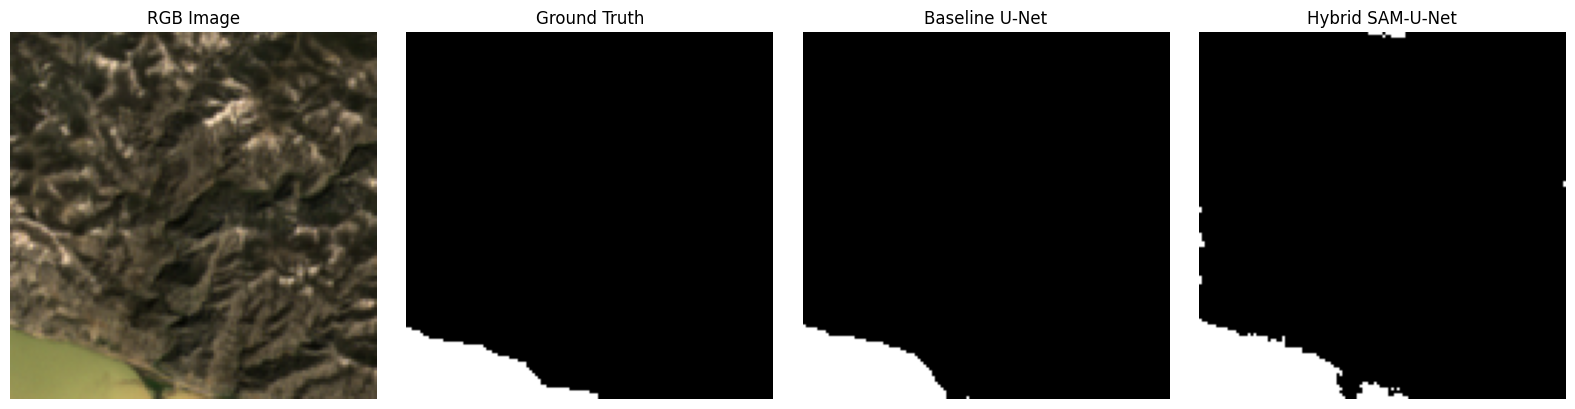

In [260]:
import matplotlib.pyplot as plt
import torch

baseline_model.eval()
hybrid_model.eval()

images, masks, sams = next(iter(test_loader))

idx = 0

image = images[idx:idx+1].to(DEVICE)
mask = masks[idx].squeeze().cpu().numpy()
sam = sams[idx:idx+1].to(DEVICE)

with torch.no_grad():

    baseline_pred = torch.sigmoid(
        baseline_model(image)
    )

    baseline_pred = (
        baseline_pred > 0.5
    ).float()

    hybrid_pred = torch.sigmoid(
        hybrid_model(
            image,
            sam
        )
    )

    hybrid_pred = (
        hybrid_pred > 0.5
    ).float()

baseline_pred = (
    baseline_pred
    .squeeze()
    .cpu()
    .numpy()
)

hybrid_pred = (
    hybrid_pred
    .squeeze()
    .cpu()
    .numpy()
)

image = (
    image
    .squeeze()
    .permute(1, 2, 0)
    .cpu()
    .numpy()
)

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(baseline_pred, cmap="gray")
plt.title("Baseline U-Net")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(hybrid_pred, cmap="gray")
plt.title("Hybrid SAM-U-Net")
plt.axis("off")

plt.tight_layout()
plt.show()

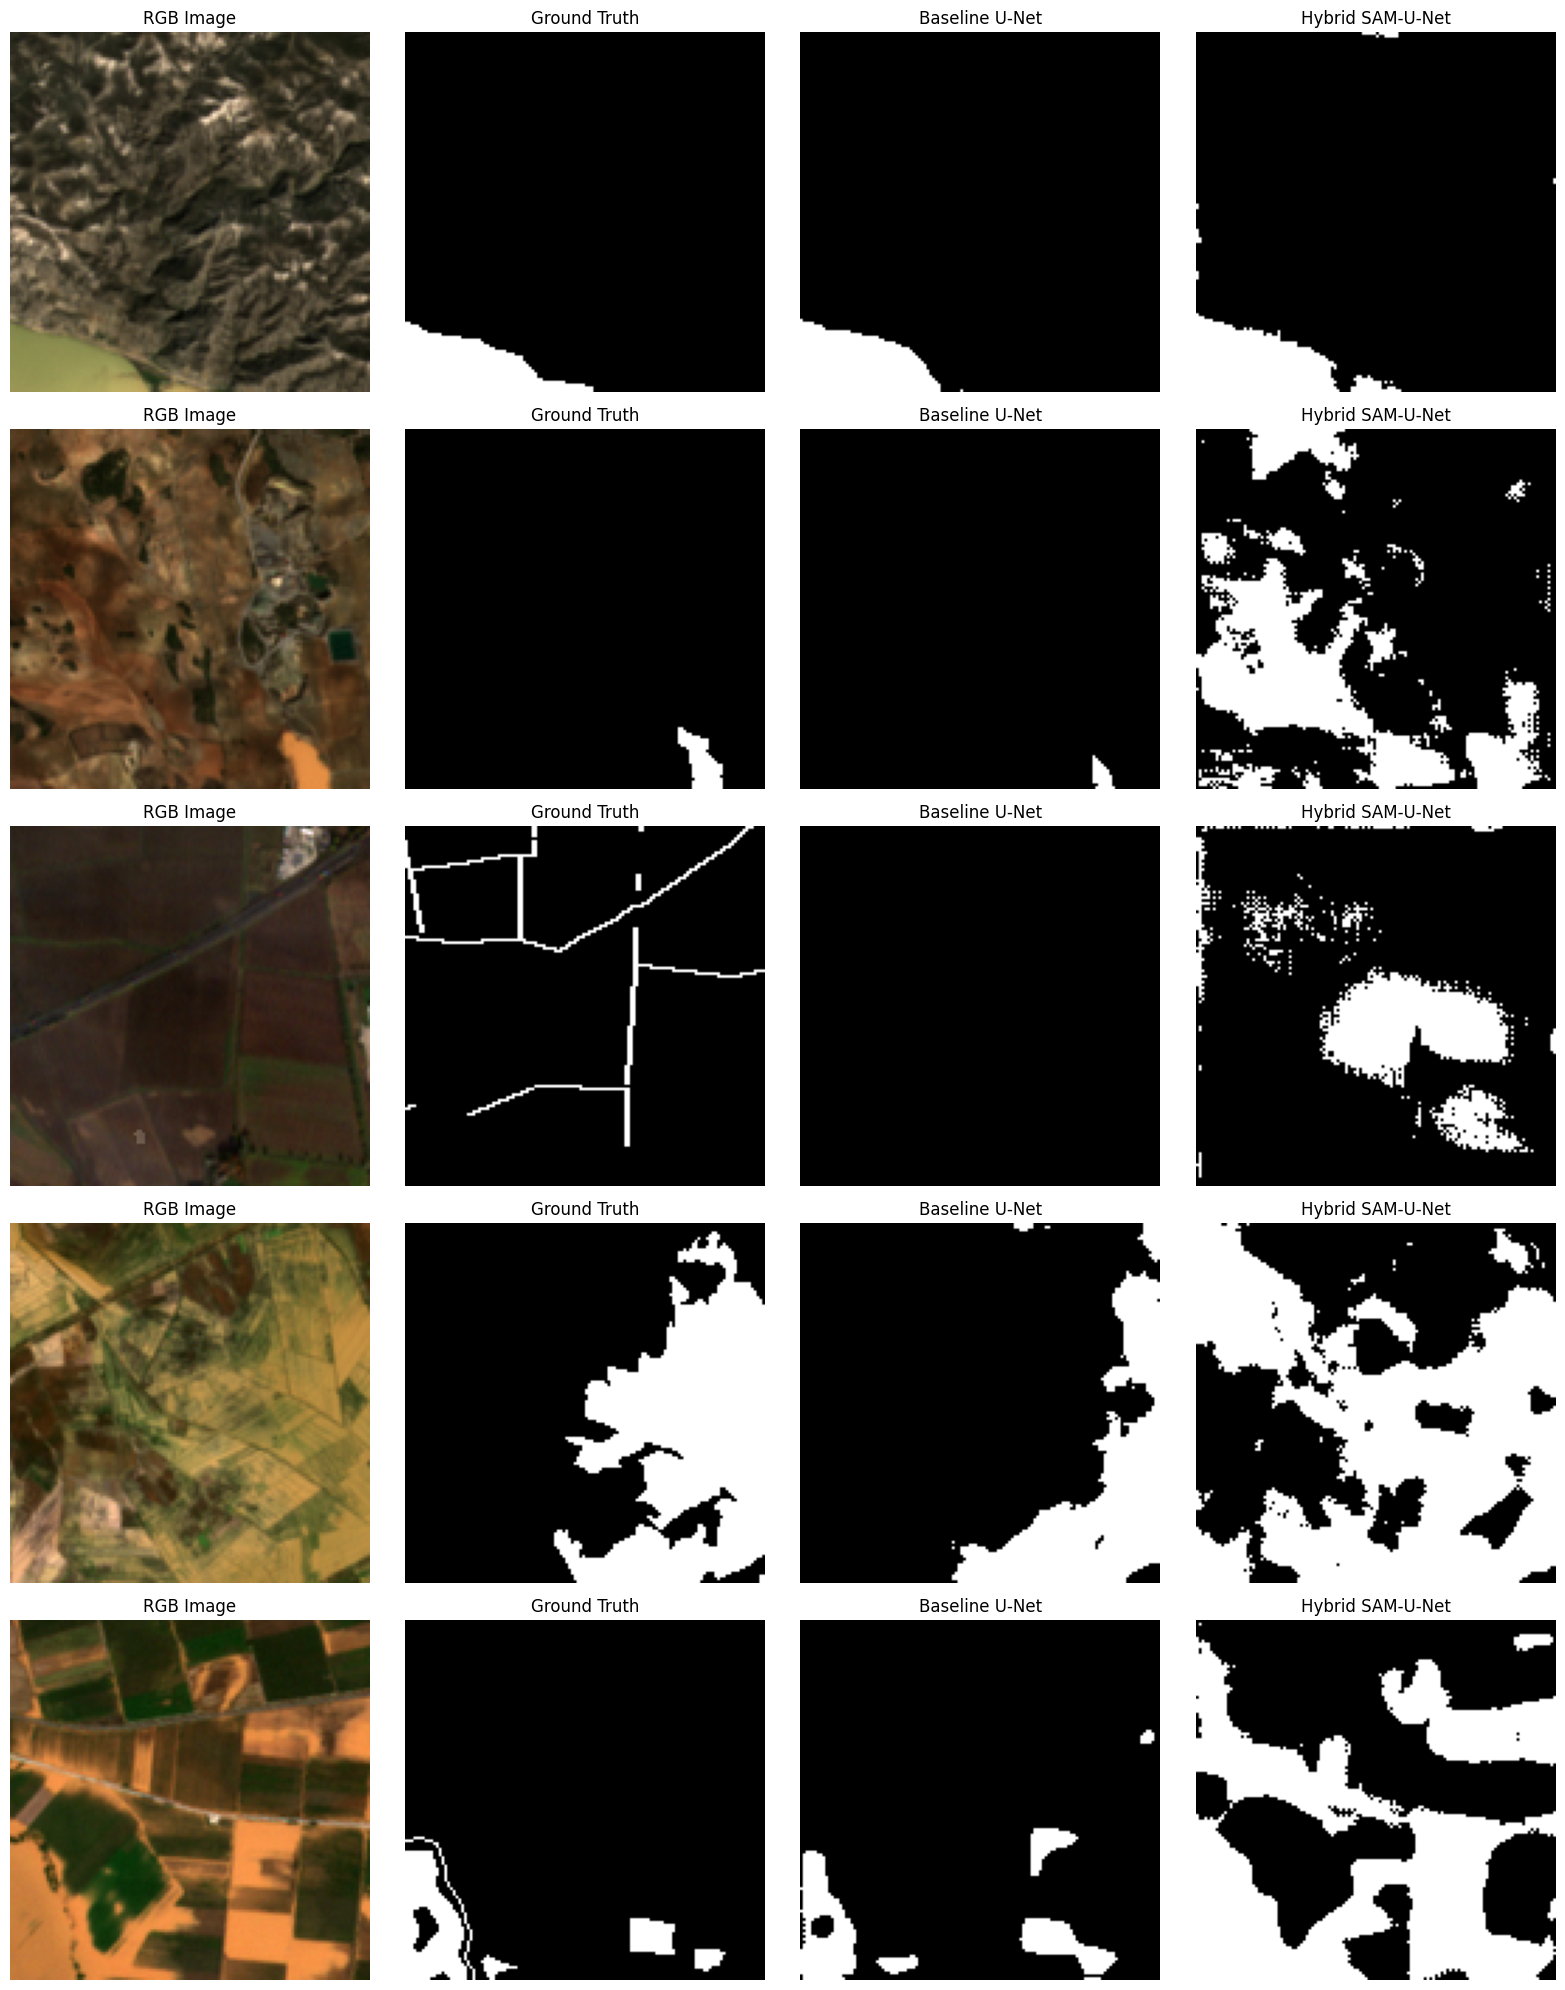

In [263]:
import matplotlib.pyplot as plt
import torch

baseline_model.eval()
hybrid_model.eval()

# Change these indices as needed
sample_indices = [0, 25, 50, 75, 100]

fig, axes = plt.subplots(
    len(sample_indices),
    4,
    figsize=(16, 4 * len(sample_indices))
)

for row, idx in enumerate(sample_indices):

    image, mask, sam = test_dataset[idx]

    image_input = image.unsqueeze(0).to(DEVICE)
    sam_input = sam.unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        baseline_pred = baseline_model(
            image_input
        )

        baseline_pred = (
            torch.sigmoid(
                baseline_pred
            ) > 0.5
        ).float()

        hybrid_pred = hybrid_model(
            image_input,
            sam_input
        )

        hybrid_pred = (
            torch.sigmoid(
                hybrid_pred
            ) > 0.5
        ).float()

    rgb = (
        image
        .permute(1, 2, 0)
        .cpu()
        .numpy()
    )

    gt_mask = (
        mask
        .squeeze()
        .cpu()
        .numpy()
    )

    baseline_pred = (
        baseline_pred
        .squeeze()
        .cpu()
        .numpy()
    )

    hybrid_pred = (
        hybrid_pred
        .squeeze()
        .cpu()
        .numpy()
    )

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title("RGB Image")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        gt_mask,
        cmap="gray"
    )
    axes[row, 1].set_title("Ground Truth")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(
        baseline_pred,
        cmap="gray"
    )
    axes[row, 2].set_title("Baseline U-Net")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(
        hybrid_pred,
        cmap="gray"
    )
    axes[row, 3].set_title("Hybrid SAM-U-Net")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.show()